# PROBLEM STATEMENT

<table>
  <tr><td>
    <img src="https://upload.wikimedia.org/wikipedia/commons/1/14/Amazon_Echo_Dot_%28black%29_on_a_wood_surface.jpg"
alt="Fashion MNIST sprite"  length = "400" width="400">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1. Amazon Alexa Reviews Classification [Source: https://en.wikipedia.org/wiki/Amazon_Echo]
  </td></tr>
</table>


- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews
---

# STEP #0: IMPORT LIBRARIES

In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Prevent TensorFlow from reserving most GPU memory upfront

gpu = tf.config.experimental.list_physical_devices('GPU')
if gpu:
    try:
        tf.config.experimental.set_memory_growth(gpu[0], True)
    except RuntimeError as e:
        print(e)
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", gpu)

I0000 00:00:1774117350.556907   38216 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774117350.601290   38216 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774117351.325620   38216 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1774117352.611555   38216 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


# STEP #1: IMPORT DATASETS

In [2]:
reviews_data = pd.read_csv("../data/amazon_alexa.tsv", sep="\t")
reviews_data.reset_index(drop=True, inplace=True)
reviews_data

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1
...,...,...,...,...,...
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1


In [3]:
reviews_data.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [4]:
reviews_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   rating            3150 non-null   int64
 1   date              3150 non-null   str  
 2   variation         3150 non-null   str  
 3   verified_reviews  3149 non-null   str  
 4   feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 123.2 KB


# STEP #2: VISUALIZE DATASET

In [5]:
positive = reviews_data[reviews_data["feedback"] == 1]
negative = reviews_data[reviews_data["feedback"] == 0]

print("Positive reviews:", len(positive))
print("Negative reviews:", len(negative))

Positive reviews: 2893
Negative reviews: 257


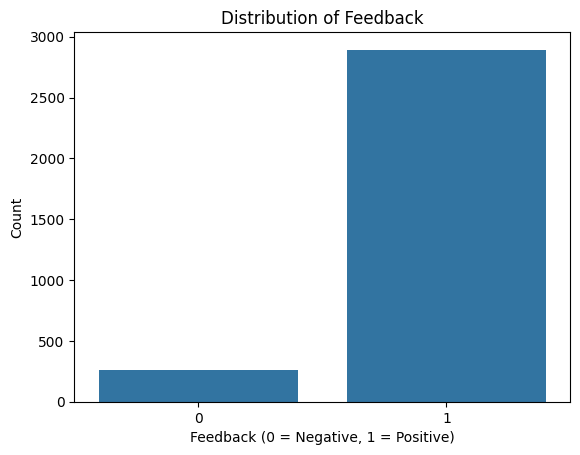

In [6]:
sns.countplot(x="feedback", data=reviews_data)
plt.title("Distribution of Feedback")
plt.xlabel("Feedback (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

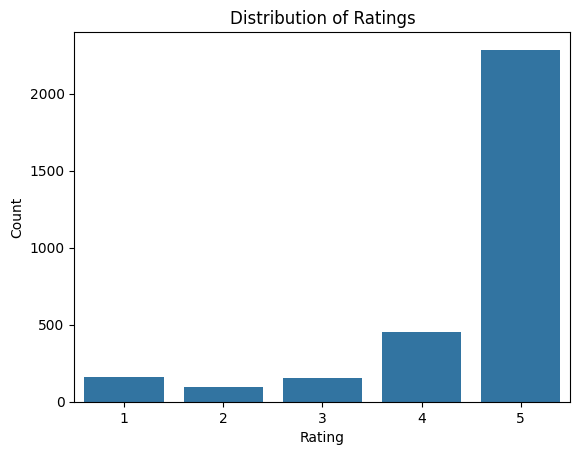

In [7]:
sns.countplot(x="rating", data=reviews_data)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

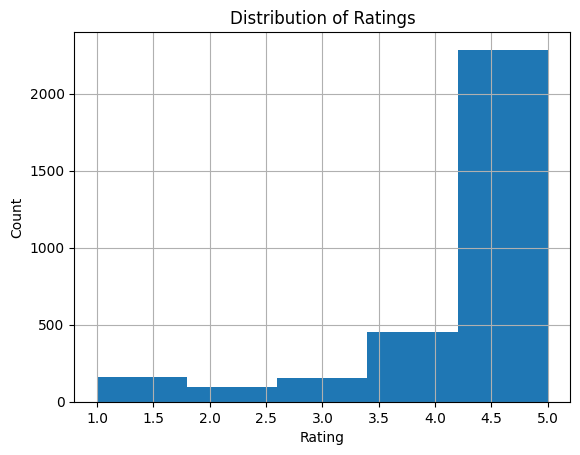

In [8]:
reviews_data['rating'].hist(bins=5)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

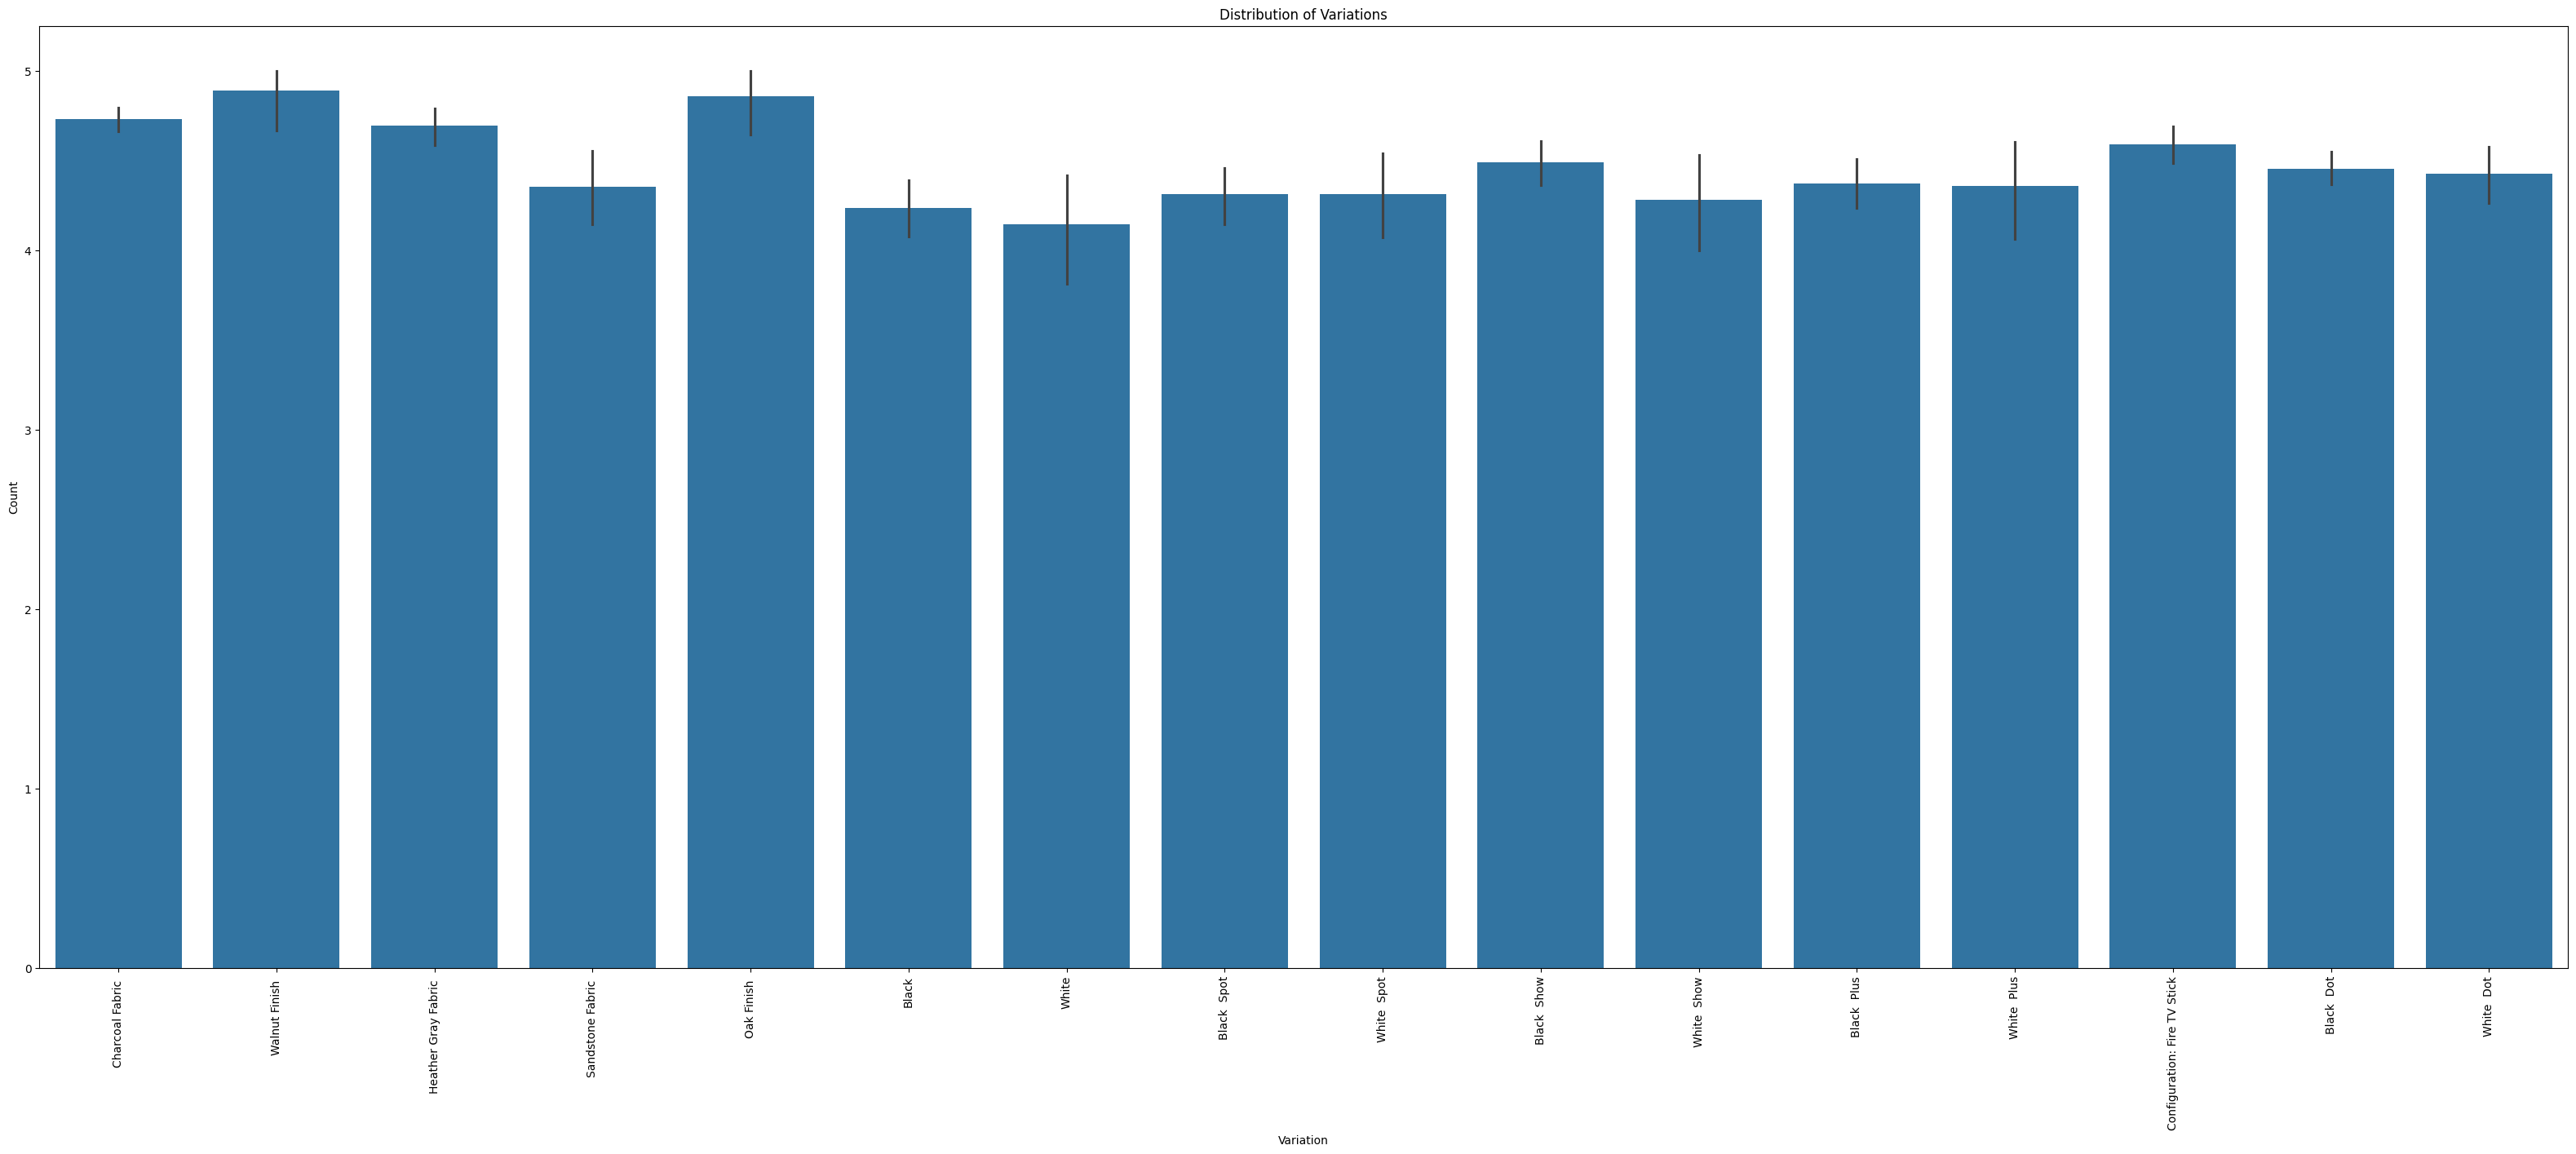

In [9]:
plt.figure(figsize=(40, 15))
sns.barplot(x="variation", y = "rating", data=reviews_data)
plt.title("Distribution of Variations")
plt.xlabel("Variation")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

# STEP #3: CLEAN UP THE DATA 

In [10]:
reviews_data = reviews_data.drop(labels=["date", "rating"], axis=1)
reviews_data

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1
...,...,...,...
3145,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,Black Dot,"Listening to music, searching locations, check...",1
3147,Black Dot,"I do love these things, i have them running my...",1
3148,White Dot,Only complaint I have is that the sound qualit...,1


In [11]:
variantion_dummies = pd.get_dummies(reviews_data["variation"], drop_first=True)
variantion_dummies

,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,Walnut Finish,White,White Dot,White Plus,White Show,White Spot
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3146,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3147,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3148,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [12]:
reviews_data = reviews_data.drop(labels=["variation"], axis=1)
reviews_data

,verified_reviews,feedback
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1
...,...,...
3145,"Perfect for kids, adults and everyone in betwe...",1
3146,"Listening to music, searching locations, check...",1
3147,"I do love these things, i have them running my...",1
3148,Only complaint I have is that the sound qualit...,1


In [13]:

reviews_data = pd.concat([reviews_data, variantion_dummies], axis=1)
reviews_data

,verified_reviews,feedback,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,Walnut Finish,White,White Dot,White Plus,White Show,White Spot
0,Love my Echo!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,Loved it!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"Sometimes while playing a game, you can answer...",1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,I have had a lot of fun with this thing. My 4 ...,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,Music,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,"Perfect for kids, adults and everyone in betwe...",1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3146,"Listening to music, searching locations, check...",1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3147,"I do love these things, i have them running my...",1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3148,Only complaint I have is that the sound qualit...,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


# Count Vectorizer (Tokenization) Example


In [14]:
from sklearn.feature_extraction.text import CountVectorizer  # Importa o tokenizador baseado em contagem de palavras
sample_data = ['This is the first document.','This document is the second document.','And this is the third one.','Is this the first document?']  # Frases de exemplo para montar o vocabulário

vectorizer = CountVectorizer()  # Cria o vetor de contagem com configuracao padrao
X = vectorizer.fit_transform(sample_data)  # Aprende o vocabulario e transforma os textos em matriz esparsa de frequencias

In [15]:
# Exibe os tokens (palavras) unicas aprendidas pelo modelo
print(vectorizer.get_feature_names_out()) 

['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']


In [16]:
# Converte a matriz esparsa para array denso e mostra a contagem de cada token por frase
print(X.toarray()) # type: ignore

[[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]


# Back to our Case Study!

In [17]:
vectorizer = CountVectorizer()
reviews_text = reviews_data["verified_reviews"].fillna("")  # Remove NaN para evitar erro no CountVectorizer
reviews_countvect = vectorizer.fit_transform(reviews_text)  # Aprende o vocabulario e transforma os textos em matriz esparsa de frequencias
reviews_countvect.shape

(3150, 4044)

In [18]:
print(vectorizer.get_feature_names_out())

['00' '000' '07' ... 'zzzz' 'zzzzzzz' 'útil']


In [19]:
print(reviews_countvect.toarray()) # type: ignore

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [20]:
reviews_data.drop(labels=["verified_reviews"], axis=1, inplace=True)
reviews = pd.DataFrame(reviews_countvect.toarray()) # type: ignore

reviews_data = pd.concat([reviews_data, reviews], axis=1)
reviews_data

,feedback,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,...,4034,4035,4036,4037,4038,4039,4040,4041,4042,4043
0,1,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,True,False,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,1,True,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3146,1,True,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3147,1,True,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3148,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [27]:
# Converte todas as features para float32 para compatibilidade com TensorFlow
X = reviews_data.drop(labels=["feedback"], axis=1).astype("float32")
Y = reviews_data["feedback"].astype("float32")

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (2520, 4059)
Y_train shape: (2520,)
X_test shape: (630, 4059)
Y_test shape: (630,)


# STEP #4: TRAIN THE MODEL

In [67]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(400, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(800, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(400, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

In [68]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 400)            │     1,624,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 800)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 400)            │       320,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,601 (8.64 MB)

 Trainable params: 2,265,601 (8.64 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
model.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

In [70]:
with tf.device("/GPU:0"):
    epochs_history = model.fit(X_train, Y_train, epochs=20)
    print("Training finished.")
    print("Learned weight:", model.layers[0].get_weights()[0][0][0])
    print("Learned bias:", model.layers[0].get_weights()[1][0])
    print("Initial loss:", float(epochs_history.history["loss"][0]))
    print("Final loss:", float(epochs_history.history["loss"][-1]))

Epoch 1/20


I0000 00:00:1774118567.609846   38323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47826__.10


58/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9123 - loss: 0.3572

I0000 00:00:1774118568.735665   38322 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47826__.10


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9214 - loss: 0.2513
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9738 - loss: 0.0759
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9881 - loss: 0.0307
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0208
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0182
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9917 - loss: 0.0241
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0168
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9921 - loss: 0.0154
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0142
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0142 
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9933 - loss: 0.0142 
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9929 - loss: 0.01

# STEP #5: EVALUATE THE MODEL

In [71]:
Y_pred_train = model.predict(X_train)
Y_pred_train

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([[0.9999001],
       [1.       ],
       [1.       ],
       ...,
       [1.       ],
       [1.       ],
       [1.       ]], shape=(2520, 1), dtype=float32)

In [72]:
Y_pred_train = (Y_pred_train > 0.5)
Y_pred_train

array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]], shape=(2520, 1))

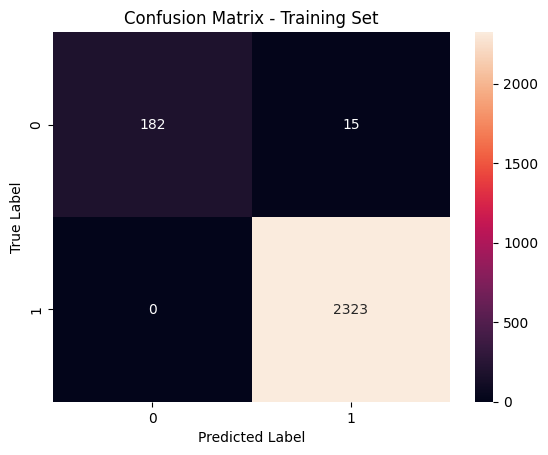

In [78]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_train, Y_pred_train)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Training Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [79]:
Y_pred_test = model.predict(X_test)
Y_pred_test = (Y_pred_test > 0.5)
Y_pred_test

 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [

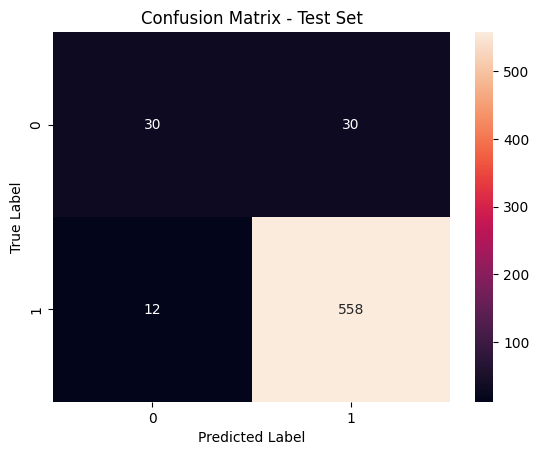

In [80]:
cm = confusion_matrix(Y_test, Y_pred_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

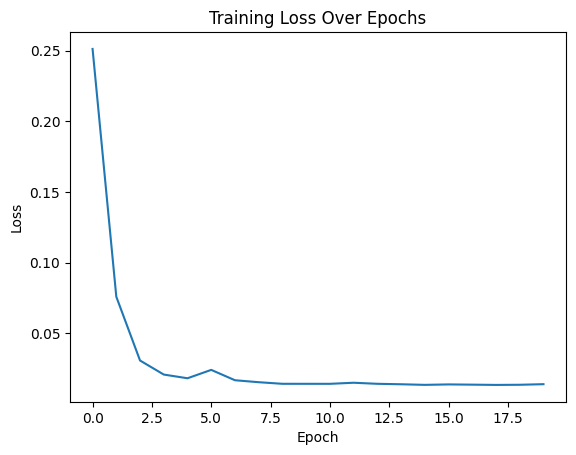

In [81]:
plt.plot(epochs_history.history["loss"])
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

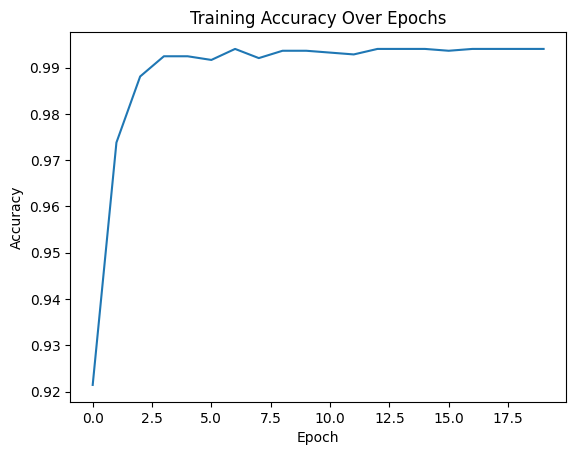

In [82]:
plt.plot(epochs_history.history["accuracy"])
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()